In [1]:
!pip install tensorflow scikit-learn matplotlib -q

In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = load_iris()
X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Classes:", np.unique(y))
print("Class names:", data.target_names)

Feature shape: (150, 4)
Classes: [0 1 2]
Class names: ['setosa' 'versicolor' 'virginica']


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = keras.Sequential([
    keras.layers.Dense(3, activation='softmax', input_shape=(X.shape[1],))
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.5417 - loss: 0.9964 - val_accuracy: 0.5417 - val_loss: 1.0056
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5521 - loss: 0.9662 - val_accuracy: 0.5417 - val_loss: 0.9827
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5729 - loss: 0.9401 - val_accuracy: 0.5417 - val_loss: 0.9608
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5938 - loss: 0.9148 - val_accuracy: 0.6250 - val_loss: 0.9407
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6354 - loss: 0.8901 - val_accuracy: 0.6250 - val_loss: 0.9225
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6562 - loss: 0.8679 - val_accuracy: 0.6250 - val_loss: 0.9044
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6667 - loss: 0.8468 - val_accuracy: 0.6250 - val_loss: 0.8875
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6979 - loss: 0.8266 - val_accuracy: 0.6250 - v

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step - accuracy: 0.9333 - loss: 0.4650
Test Accuracy: 0.9333333373069763
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step

Confusion Matrix:
[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



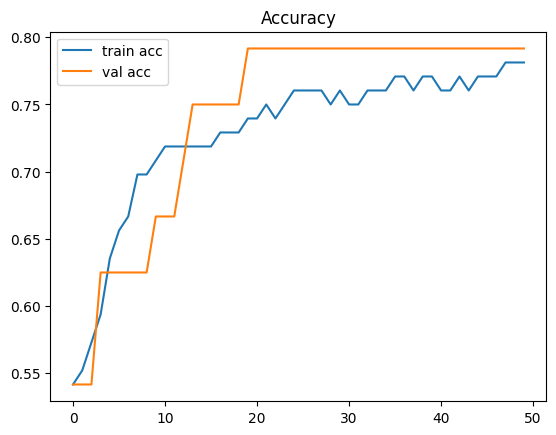

In [8]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

In [9]:
# Example input: [sepal length, sepal width, petal length, petal width]
sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# Apply same scaling
sample = scaler.transform(sample)

prediction = model.predict(sample)
class_index = np.argmax(prediction)

print("Raw probabilities:", prediction)
print("Predicted class:", data.target_names[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Raw probabilities: [[0.91116357 0.05701385 0.03182261]]
Predicted class: setosa
